# 01. Preparing Sequence Data — Keras (RNN/LSTM)

Before any recurrent layer, raw data must become **sequences of vectors**. Text and time-series get there very differently — this notebook shows both, and builds the cached arrays every later notebook reuses.

**Two datasets, one concept:**
- **A) IMDB** movie reviews — many-to-one *text classification* (metric: accuracy).
- **B) Jena Climate** weather — sliding-window *temperature forecasting* (metric: MAE).

> Data prep lives in `rnn_data.py`; run `01_sequence_data_prep` once to build the caches.

---

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rnn_data as R                      # shared loaders (see rnn_data.py)
keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


In [2]:
def plot_history(h, metric, title=""):
    """Train (solid) vs validation (dashed): loss on the left, `metric` on the right."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], "--", label="val")
    ax[0].set_title(title + " — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h.history[metric], label="train")
    ax[1].plot(h.history["val_" + metric], "--", label="val")
    ax[1].set_title(title + " — " + metric); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 0. Build the caches (downloads on first run)

This downloads IMDB (~18 MB) and Jena Climate (~14 MB), preprocesses them, and writes small `.npz` caches next to the notebooks. Re-running is instant.

In [3]:
R.build_imdb_cache()
R.build_jena_cache()

C:\Users\Milan Amrut Joshi\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


IMDB cached: (8000, 150) (4000, 150) | vocab 10000 | maxlen 150


Jena cached: (20000, 14) | features 14 | target 'T (degC)' idx 1 | n_train 12000


'C:\\Users\\Milan Amrut Joshi\\Desktop\\Misc_2\\Deep_Learning\\Session1_2_3\\notebooks_RNN_LSTM\\jena_prepared.npz'

## Part A — IMDB: text → integer sequences → embeddings

Reviews arrive as **lists of word indices** (already tokenized by Keras). We (1) cap the vocabulary, (2) **pad/truncate** to a fixed length, and (3) let an `Embedding` layer learn a dense vector per word.

In [4]:
# raw (variable-length) reviews, straight from Keras
(raw_x, raw_y), _ = keras.datasets.imdb.load_data(num_words=10000)
print("A review is a list of word indices:")
print(raw_x[0][:20], "...")
print("label:", raw_y[0], "(1 = positive, 0 = negative)")

# decode the first review back to words
wi = keras.datasets.imdb.get_word_index()
idx_word = {v + 3: k for k, v in wi.items()}
idx_word[0], idx_word[1], idx_word[2] = "<pad>", "<start>", "<unk>"
print("\nDecoded:", " ".join(idx_word.get(i, "?") for i in raw_x[0][:40]), "...")

C:\Users\Milan Amrut Joshi\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


A review is a list of word indices:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...
label: 1 (1 = positive, 0 = negative)


      0/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  16384/1641221 ━━━━━━━━━━━━━━━━━━━━ 9s 6us/step

  24576/1641221 ━━━━━━━━━━━━━━━━━━━━ 13s 8us/step

...

1540096/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step

1581056/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step

1613824/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 7s 5us/step



Decoded: <start> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came ...


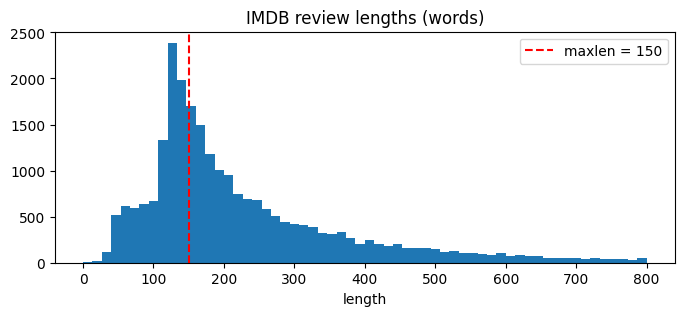

median length: 178


In [5]:
# review-length distribution motivates a fixed maxlen
lengths = [len(r) for r in raw_x]
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=60, range=(0, 800))
plt.axvline(150, color="red", ls="--", label="maxlen = 150")
plt.title("IMDB review lengths (words)"); plt.xlabel("length"); plt.legend(); plt.show()
print("median length:", int(np.median(lengths)))

In [6]:
# the cached, padded arrays every later notebook uses
Xtr, ytr, Xte, yte = R.load_imdb()
print("Padded shape:", Xtr.shape, "(samples, maxlen) — note the leading 0s are padding:")
print(Xtr[0][:20])

# an Embedding turns each index into a learned vector
emb = layers.Embedding(10000, 8)
demo = emb(Xtr[:1])           # (1, maxlen, 8)
print("Embedding output shape:", demo.shape, "-> (batch, timesteps, embedding_dim)")

Padded shape: (8000, 150) (samples, maxlen) — note the leading 0s are padding:
[  12   16   43  530   38   76   15   13 1247    4   22   17  515   17
   12   16  626   18    2    5]


Embedding output shape: (1, 150, 8) -> (batch, timesteps, embedding_dim)


## Part B — Jena: time-series → standardized sliding windows

Weather is one long multivariate series. We (1) resample to hourly, (2) **standardize** using *training* statistics only (no leakage), and (3) cut **sliding windows**: the last *N* hours predict the temperature at the next hour.

Standardized series: (20000, 14) (timesteps, features)
Features: [np.str_('p (mbar)'), np.str_('T (degC)'), np.str_('Tpot (K)'), np.str_('Tdew (degC)'), np.str_('rh (%)'), np.str_('VPmax (mbar)'), np.str_('VPact (mbar)'), np.str_('VPdef (mbar)'), np.str_('sh (g/kg)'), np.str_('H2OC (mmol/mol)'), np.str_('rho (g/m**3)'), np.str_('wv (m/s)'), np.str_('max. wv (m/s)'), np.str_('wd (deg)')]


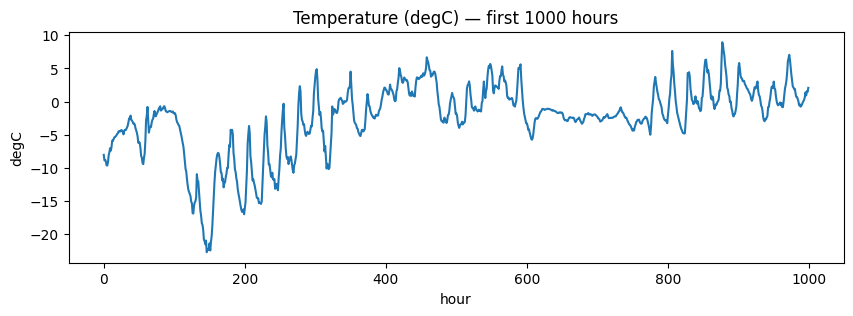

In [7]:
s = R.load_jena_series()
print("Standardized series:", s["data"].shape, "(timesteps, features)")
print("Features:", s["feature_names"])
temp_c = s["temp_norm"] * s["temp_std"] + s["temp_mean"]   # de-standardize for a readable plot

plt.figure(figsize=(10, 3))
plt.plot(temp_c[:1000])
plt.title("Temperature (degC) — first 1000 hours"); plt.xlabel("hour"); plt.ylabel("degC"); plt.show()

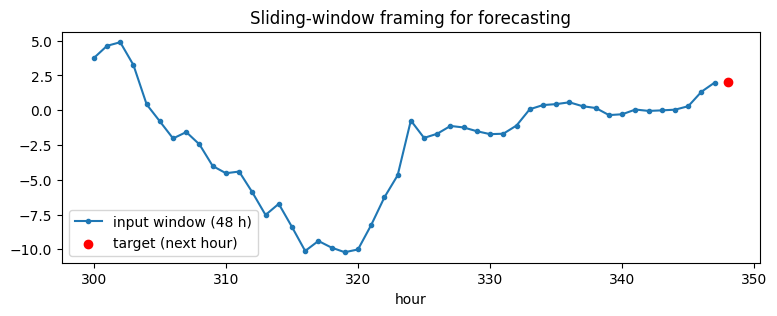

In [8]:
# illustrate ONE training window -> target
i, L = 300, 48
plt.figure(figsize=(9, 3))
plt.plot(range(i, i + L), temp_c[i:i + L], marker=".", label="input window (48 h)")
plt.scatter([i + L], [temp_c[i + L]], color="red", zorder=5, label="target (next hour)")
plt.title("Sliding-window framing for forecasting"); plt.xlabel("hour"); plt.legend(); plt.show()

In [9]:
# the windowed tf.data pipeline used by later notebooks
train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=48, horizon=1, batch_size=128)
for xb, yb in train_ds.take(1):
    print("Batch of windows:", xb.shape, "-> (batch, timesteps, features)")
    print("Targets:", yb.shape, "-> one temperature per window")
print("n_features:", nfeat)

Batch of windows: (128, 48, 14) -> (batch, timesteps, features)
Targets: (128,) -> one temperature per window
n_features: 14


## Takeaways
- **Text** becomes sequences via *tokenize → pad → embed*; the `Embedding` layer is a learned lookup table `(vocab → dense vector)`.
- **Time-series** becomes sequences via *standardize → window*; each sample is `(timesteps, features)` and the target is a future value.
- Both end up as a 3-D tensor **`(batch, timesteps, features)`** — exactly what every RNN/LSTM layer expects. That shared shape is why the same layers work on both.
- Standardize using **training statistics only** — computing mean/std over the whole series leaks the future into the past.
- **Next:** `02_simplernn` — the simplest recurrent layer on both datasets.